**IMPORT LIBRARIES**

In [1]:
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
import re, nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from wordcloud import WordCloud
from nltk import PorterStemmer, WordNetLemmatizer
from nltk import sent_tokenize
from nltk.tokenize import word_tokenize
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [2]:
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


**LOAD DATASET**

In [4]:
df = pd.read_csv("/kaggle/input/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset/Dataset-SA.csv")
df.head()

,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [5]:
print(df.shape)

(205052, 6)


In [6]:
print(df.columns.tolist())

['product_name', 'product_price', 'Rate', 'Review', 'Summary', 'Sentiment']


In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB
None


In [8]:
print(df["Sentiment"].value_counts())

Sentiment
positive    166581
negative     28232
neutral      10239
Name: count, dtype: int64


**DATA CLEANING**

In [9]:
df.isna().sum()

product_name         0
product_price        0
Rate                 0
Review           24664
Summary             11
Sentiment            0
dtype: int64

In [10]:
df.dropna(subset=['Review'],inplace=True)

In [11]:
df.dropna(subset=['Summary'],inplace=True)

In [12]:
print(df.duplicated())

0         False
1         False
2         False
3         False
4         False
          ...  
205047     True
205048     True
205049    False
205050    False
205051    False
Length: 180379, dtype: bool


In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154467 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   154467 non-null  object
 1   product_price  154467 non-null  object
 2   Rate           154467 non-null  object
 3   Review         154467 non-null  object
 4   Summary        154467 non-null  object
 5   Sentiment      154467 non-null  object
dtypes: object(6)
memory usage: 8.2+ MB


In [15]:
print(df.head(3)[["Review","Sentiment","Rate"]])

    Review Sentiment Rate
0   super!  positive    5
1  awesome  positive    5
2     fair  positive    3


**SENTIMENT DISTRIBUTION**

In [16]:
for sent in ["positive", "neutral", "negative"]:
    sample = df[df.Sentiment==sent]["Review"].iloc[0]
    print(f"\n{sent.upper()}:\n{sample}")


POSITIVE:
super!

NEUTRAL:
fair

NEGATIVE:
useless product


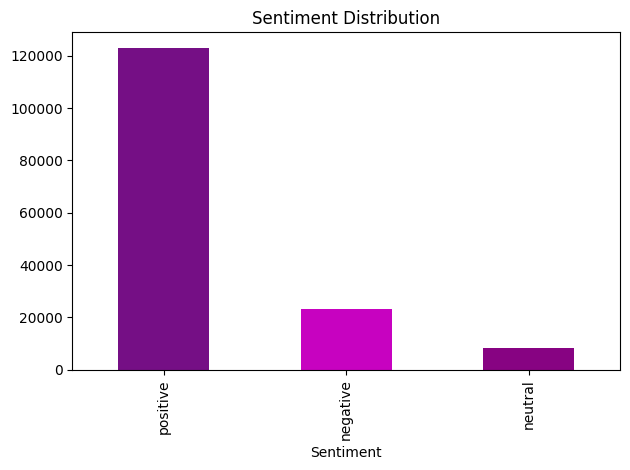

In [17]:
df["Sentiment"].value_counts().plot(kind="bar", color = ["#750f85", "#c702c0","#870382"], title = "Sentiment Distribution")
plt.tight_layout()
plt.show()

**WORD TOKENIZATION**

In [18]:
def preprocess(text):
    text   = text.lower()
    text   = re.sub(r'[^a-zA-Z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t)
              for t in tokens
              if t not in stop_words
              and len(t) > 2]
    return ' '.join(tokens)


In [19]:
df["cleaned_text"] = df['Summary'].apply(preprocess)
pos_words = ' '.join(df[df.Sentiment == 'positive']['cleaned_text'])
neg_words = ' '.join(df[df.Sentiment == 'negative']['cleaned_text'])
neu_words = ' '.join(df[df.Sentiment == 'neutral']['cleaned_text'])
print('completed!')

completed!


In [20]:
pos_split=Counter(pos_words.split()).most_common(10)
neg_split=Counter(neg_words.split()).most_common(10)
neu_split=Counter(neu_words.split()).most_common(10)

**DISTRIBUTION PLOT**

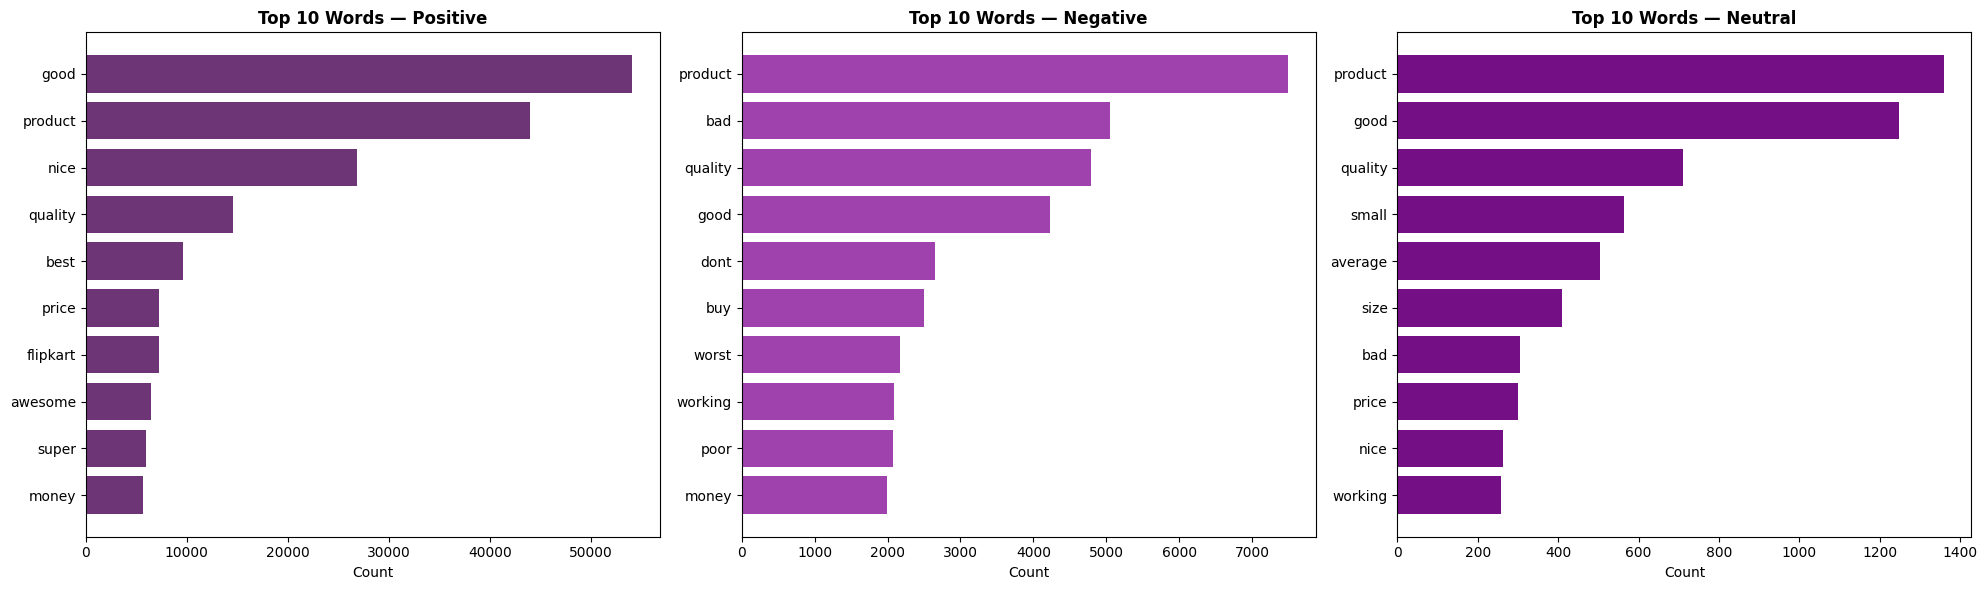

In [21]:
fig, axes = plt.subplots(1,3,figsize=(20,6))
data=[pos_split,neg_split,neu_split]
color=["#6d3575","#9f42ad","#750f85"]
labels=["Positive","Negative","Neutral"]
for ax,dt,clr,lbl in zip(axes,data,color,labels):
  w,c = zip(*dt)
  ax.barh(list(w)[::-1],list(c)[::-1],color=clr)
  ax.set_xlabel("Count")
  ax.set_title(f'Top 10 Words — {lbl}', fontweight='bold')
plt.tight_layout()
plt.show()

**WORD CLOUD**

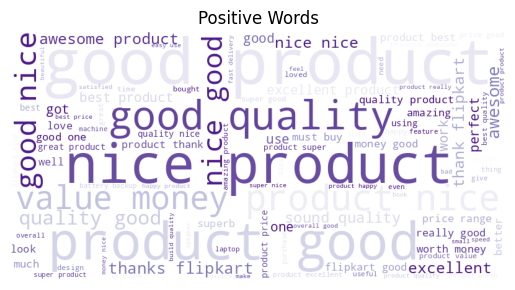

In [22]:
wc = WordCloud(width=800, height=400,background_color="white", colormap="Purples", max_words=100,
               min_font_size =10,contour_color='blue').generate(pos_words)

ax = plt.axes()
ax.imshow(wc)
ax.axis("off")
ax.set_title("Positive Words")
plt.show()

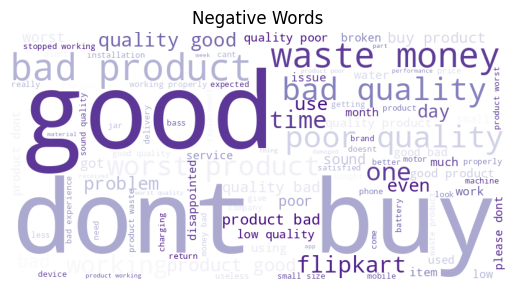

In [23]:
wc = WordCloud(width=800, height=400,background_color="white", colormap="Purples", max_words=100,
               min_font_size =10,contour_color='blue').generate(neg_words)

ax = plt.axes()
ax.imshow(wc)
ax.axis("off")
ax.set_title("Negative Words")
plt.show()

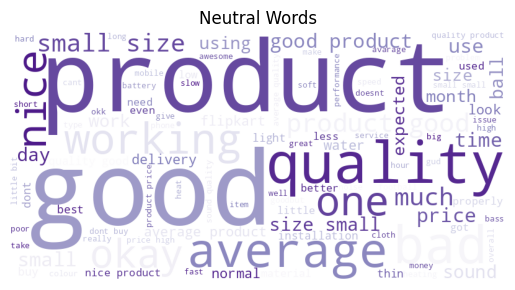

In [24]:
wc = WordCloud(width=800, height=400,background_color="white", colormap="Purples", max_words=100,
               min_font_size =10,contour_color='blue').generate(neu_words)

ax = plt.axes()
ax.imshow(wc)
ax.axis("off")
ax.set_title("Neutral Words")
plt.show()

**LABEL ENCODING**

In [25]:
le = LabelEncoder()
df['Label'] = le.fit_transform(df['Sentiment'])

In [26]:
print(df['Label'].head(5))

0    2
1    2
2    2
3    0
4    1
Name: Label, dtype: int64


**FEATURE AND TARGET DEFINITION**

In [27]:
X = df["cleaned_text"]
y = df["Label"]

**TF - IDF MATRIX**

In [28]:
tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,2),min_df = 2)

**TRAIN AND FIT**

In [29]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify=y)
X_train_tfidf = tfidf.fit_transform(X_train)

In [30]:
X_test_tfidf = tfidf.transform(X_test)
print(f"Train matrix size: {X_train_tfidf.shape}")
print(f"Test matrix size: {X_test_tfidf.shape}")

Train matrix size: (123573, 5000)
Test matrix size: (30894, 5000)


**LOGISTIC REGRESSION**

In [31]:
clf = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
clf.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

**PREDICTION**

In [32]:
y_pred = clf.predict(X_test_tfidf)

**ACCURACY SCORE AND CLASSIFICATION REPORT**

In [33]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc: .2%}")
print(classification_report(y_test, y_pred,target_names=["positive","negative","neutral"]))

Accuracy:  83.09%
              precision    recall  f1-score   support

    positive       0.69      0.75      0.72      4671
    negative       0.28      0.69      0.39      1661
     neutral       0.97      0.86      0.91     24562

    accuracy                           0.83     30894
   macro avg       0.65      0.77      0.67     30894
weighted avg       0.89      0.83      0.85     30894



**CONFUSION MATRIX**

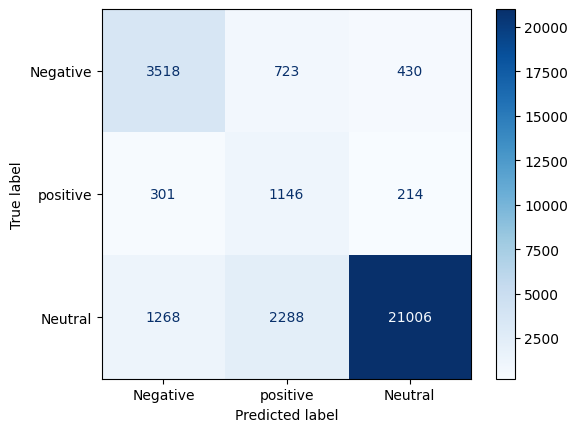

In [34]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative","positive","Neutral"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

**MODEL COMPARISON WITH RANDOM FOREST**

In [35]:
rf_clf = RandomForestClassifier(n_estimators=50,max_depth=10, random_state=42, class_weight='balanced', n_jobs=1)
rf_clf.fit(X_train_tfidf, y_train)
y_pred_rf = rf_clf.predict(X_test_tfidf)

**RF ACCURACY SCORE**

In [36]:
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf): .2%}")

Accuracy:  77.66%


**RF CLASSIFICATION REPORT**

In [37]:
print(classification_report(y_test, y_pred_rf,target_names=["positive","negative","neutral"]))

              precision    recall  f1-score   support

    positive       0.77      0.59      0.67      4671
    negative       0.19      0.74      0.30      1661
     neutral       0.96      0.81      0.88     24562

    accuracy                           0.78     30894
   macro avg       0.64      0.72      0.62     30894
weighted avg       0.89      0.78      0.82     30894



**RF CM DISPLAY**

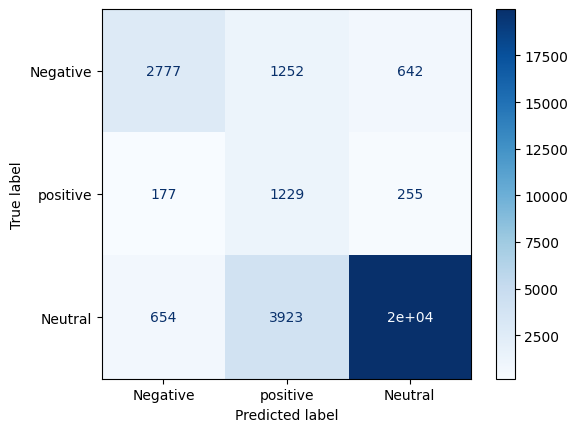

In [38]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["Negative","positive","Neutral"])
disp_rf.plot(cmap=plt.cm.Blues)
plt.show()

**CONCLUSION**

After performing data cleaning I compared two distinct machine learning models:

​**Performance Comparison**: While the Random Forest offered slightly better sensitivity for the Negative class, the Logistic Regression model emerged as the superior choice for this dataset. It achieved a higher overall accuracy of 83.05% and a more balanced F1-score across the Positive and Neutral classes.

​**Model Selection**: Logistic Regression was selected for the final pipeline due to its computational efficiency, faster training times, and better precision in distinguishing the Neutral majority from Positive signals.

